In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import data and make string data consistent.

In [15]:
df = pd.read_csv('../data/raw/Loan_Default.csv')
display(df.head())
df.shape

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


(148670, 34)

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   credit_worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  interest_rate_spread       112031 non-null  float64
 13  upfront_charges            109028 non-nu

In [18]:
str_columns = list(df.dtypes[df.dtypes == 'str'].index)
for col in str_columns:
    df[col] = df[col].str.lower().str.replace(' ','_')

# Null value checking 

In [19]:
df.isnull().sum().sort_values(ascending=False)

upfront_charges              39642
interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
ltv                          15098
property_value               15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
neg_ammortization              121
term                            41
region                           0
total_units                      0
security_type                    0
status                           0
co-applicant_credit_type         0
credit_score                     0
credit_type                      0
id                               0
secured_by                       0
occupancy_type                   0
construction_type                0
year                             0
interest_only                    0
loan_amount                      0
business_or_commerci

In [20]:
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)

upfront_charges              26.664425
interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
ltv                          10.155378
property_value               10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
neg_ammortization             0.081388
term                          0.027578
region                        0.000000
total_units                   0.000000
security_type                 0.000000
status                        0.000000
co-applicant_credit_type      0.000000
credit_score                  0.000000
credit_type                   0.000000
id                            0.000000
secured_by                    0.000000
occupancy_type                0.000000
construction_type             0.000000
year                     

# Check which columns are categorical and numerical.

In [21]:
columns = df.columns

for col in columns:
    print(f'{df[col].nunique()} {col}')

148670 id
1 year
2 loan_limit
4 gender
2 approv_in_adv
3 loan_type
4 loan_purpose
2 credit_worthiness
2 open_credit
2 business_or_commercial
211 loan_amount
131 rate_of_interest
22516 interest_rate_spread
58271 upfront_charges
26 term
2 neg_ammortization
2 interest_only
2 lump_sum_payment
385 property_value
2 construction_type
3 occupancy_type
2 secured_by
4 total_units
1001 income
4 credit_type
401 credit_score
2 co-applicant_credit_type
7 age
2 submission_of_application
8484 ltv
4 region
2 security_type
2 status
57 dtir1


In [22]:
cat_columns = df.columns[df[columns].nunique() <= 26]
for col in cat_columns:
    display(df[col].value_counts())

year
2019    148670
Name: count, dtype: int64

loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

gender
male                 42346
joint                41399
sex_not_available    37659
female               27266
Name: count, dtype: int64

approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

...

age
45-54    34720
35-44    32818
55-64    32534
65-74    20744
25-34    19142
>74       7175
<25       1337
Name: count, dtype: int64

submission_of_application
to_inst     95814
not_inst    52656
Name: count, dtype: int64

region
north         74722
south         64016
central        8697
north-east     1235
Name: count, dtype: int64

security_type
direct      148637
indriect        33
Name: count, dtype: int64

status
0    112031
1     36639
Name: count, dtype: int64

#### year columns has one value, drop it in data cleaning py. the categories look clean

In [23]:
df.head()

,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,24890,2019,cf,sex_not_available,nopre,type1,p1,l1,nopc,nob/c,...,exp,758,cib,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,male,nopre,type2,p1,l1,nopc,b/c,...,equi,552,exp,55-64,to_inst,NaN,north,direct,1,NaN
2,24892,2019,cf,male,pre,type1,p1,l1,nopc,nob/c,...,exp,834,cib,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,male,nopre,type1,p4,l1,nopc,nob/c,...,exp,587,cib,45-54,not_inst,69.376900,north,direct,0,42.0
4,24894,2019,cf,joint,pre,type1,p1,l1,nopc,nob/c,...,crif,602,exp,25-34,not_inst,91.886544,north,direct,0,39.0


# data viz

<Axes: ylabel='loan_purpose'>

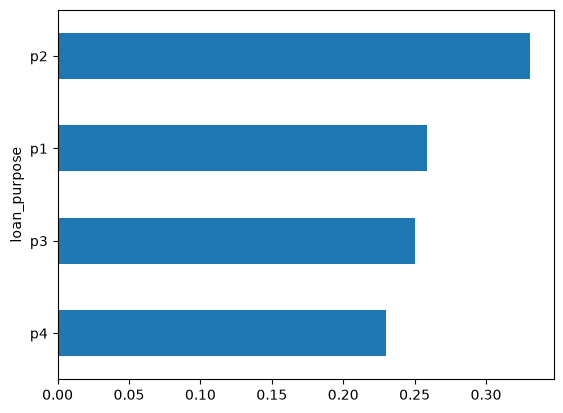

In [24]:
df.groupby('loan_purpose')['status'].mean().sort_values().plot(kind='barh')

<Axes: xlabel='credit_score', ylabel='Density'>

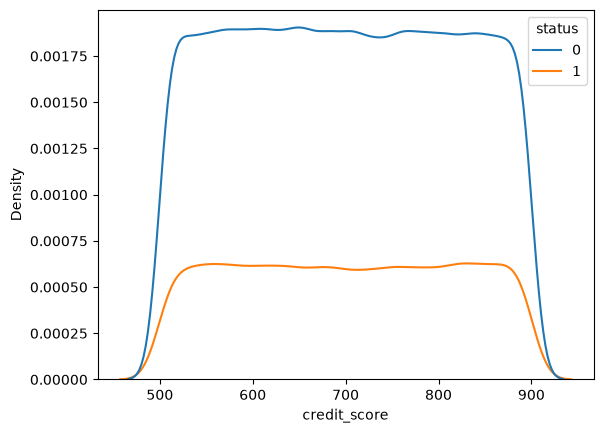

In [25]:
sns.kdeplot(data=df, x='credit_score', hue='status')

<Axes: >

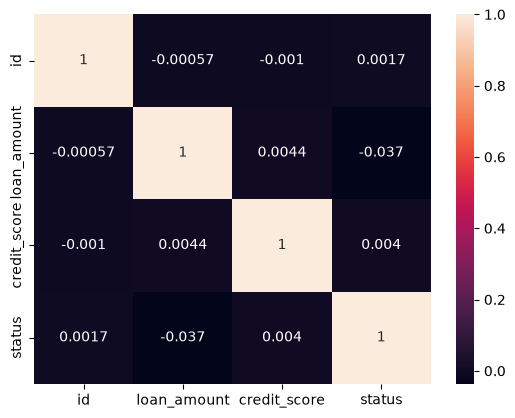

In [26]:
numerical_cols = list(df.dtypes[df.dtypes == 'int'].index)

sns.heatmap(df[numerical_cols].drop('year', axis=1).corr(), annot=True)